# **Baseline Model: Naive Bayes (Multinomial NB + TF-IDF)**

**Project:** Multilingual Classification of Urgent Disaster Response Messages  
**Input:** `humaid_processed.csv` (from Notebook 01)

This notebook:
1. Loads processed data (same split as SVM baseline for fair comparison)
2. TF-IDF vectorization (same settings as SVM)
3. Trains MultinomialNB with `class_weight`-equivalent sample weights to handle imbalance
4. Hyperparameter tuning: smoothing alpha via cross-validation
5. Evaluation: classification report, confusion matrix, per-class recall
6. Error analysis: dangerous false negatives
7. Top predictive features per class (NB interpretability advantage)

In [23]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.preprocessing import MaxAbsScaler
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
import warnings
warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 120

print("All imports successful!")

All imports successful!


## 1. Configuration and Data Loading

In [2]:
# ── Update this to your local project directory ─────────────────────────────
BASE_DIR = r"D:/NLP_PROJECT"
# ────────────────────────────────────────────────────────────────────────────

PROCESSED_CSV = os.path.join(BASE_DIR, "datasets", "processed", "humaid_processed.csv")
PLOTS_DIR     = os.path.join(BASE_DIR, "results", "plots")
os.makedirs(PLOTS_DIR, exist_ok=True)

CLASS_ORDER = [
    "Critical Rescue",
    "Resource Requests",
    "Volunteering and Donations",
    "Situational Awareness",
    "Irrelevant",
]

CLASS_COLORS = {
    "Critical Rescue":             "#d32f2f",
    "Resource Requests":           "#ff9800",
    "Volunteering and Donations":  "#4caf50",
    "Situational Awareness":       "#2196f3",
    "Irrelevant":                  "#9e9e9e",
}

df = pd.read_csv(PROCESSED_CSV)
print(f"Loaded {len(df)} rows")
print(f"Columns: {list(df.columns)}")
print(f"\nClass distribution:")
print(df["target_label"].value_counts().reindex(CLASS_ORDER))

Loaded 74227 rows
Columns: ['tweet_id', 'tweet_text', 'class_label', 'event', 'split', 'event_set', 'target_label', 'clean_text', 'text_length', 'word_count']

Class distribution:
target_label
Critical Rescue               10949
Resource Requests              2593
Volunteering and Donations    20849
Situational Awareness         25192
Irrelevant                    14644
Name: count, dtype: int64


## 2. Train / Test Split

Using HumAID's built-in splits — **identical to the SVM baseline** for a fair comparison.

In [3]:
train_df = df[df["split"] == "train"].copy()
dev_df   = df[df["split"] == "dev"].copy()
test_df  = df[df["split"] == "test"].copy()

print(f"Train: {len(train_df)}")
print(f"Dev:   {len(dev_df)}")
print(f"Test:  {len(test_df)}")

Train: 51952
Dev:   7564
Test:  14711


In [4]:
print(f"\nTrain class distribution:")
print(train_df["target_label"].value_counts().reindex(CLASS_ORDER))
print(f"\nTest class distribution:")
print(test_df["target_label"].value_counts().reindex(CLASS_ORDER))


Train class distribution:
target_label
Critical Rescue                7663
Resource Requests              1815
Volunteering and Donations    14591
Situational Awareness         17634
Irrelevant                    10249
Name: count, dtype: int64

Test class distribution:
target_label
Critical Rescue               2167
Resource Requests              516
Volunteering and Donations    4133
Situational Awareness         4993
Irrelevant                    2902
Name: count, dtype: int64


## 3. TF-IDF Vectorization

Using the **same TF-IDF settings as the SVM baseline** (unigrams + bigrams, sublinear TF, 30 000 features) so that the models differ only in the classifier — not the features.

> **Note on `sublinear_tf=True` and MultinomialNB**  
> `sublinear_tf` applies log-scaling: `tf → 1 + log(tf)`. Log-scaled values are always ≥ 1 (for non-zero counts), so they are non-negative and valid for MultinomialNB. We also apply `MaxAbsScaler` after vectorisation as an extra safety measure, which scales each feature to `[0, 1]` without centering (centering would introduce negative values).

In [5]:
tfidf = TfidfVectorizer(
    max_features=30_000,
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.95,
    sublinear_tf=True,
)

X_train_raw = tfidf.fit_transform(train_df["clean_text"])
X_dev_raw   = tfidf.transform(dev_df["clean_text"])
X_test_raw  = tfidf.transform(test_df["clean_text"])

y_train = train_df["target_label"]
y_dev   = dev_df["target_label"]
y_test  = test_df["target_label"]

print(f"TF-IDF vocabulary size: {len(tfidf.vocabulary_)}")
print(f"X_train shape: {X_train_raw.shape}")
print(f"X_test shape:  {X_test_raw.shape}")

TF-IDF vocabulary size: 30000
X_train shape: (51952, 30000)
X_test shape:  (14711, 30000)


In [6]:
# Scale to [0, 1] — required because MultinomialNB needs non-negative input
scaler = MaxAbsScaler()
X_train = scaler.fit_transform(X_train_raw)
X_dev   = scaler.transform(X_dev_raw)
X_test  = scaler.transform(X_test_raw)

print(f"Min value in X_train after scaling: {X_train.min():.4f}  (must be >= 0)")
print(f"Max value in X_train after scaling: {X_train.max():.4f}")

Min value in X_train after scaling: 0.0000  (must be >= 0)
Max value in X_train after scaling: 1.0000


## 4. Handle Class Imbalance via Sample Weights

`MultinomialNB` does not have a built-in `class_weight` parameter (unlike `LinearSVC`).  
The equivalent approach is to compute **sample weights** that are inversely proportional to class frequency, then pass them to `.fit()`.  
This is mathematically equivalent to `class_weight='balanced'` in other sklearn estimators.

In [7]:
sample_weights = compute_sample_weight(class_weight="balanced", y=y_train)

print("Sample weight stats per class:")
weight_df = pd.DataFrame({"label": y_train, "weight": sample_weights})
print(weight_df.groupby("label")["weight"].mean().reindex(CLASS_ORDER).round(4))

Sample weight stats per class:
label
Critical Rescue               1.3559
Resource Requests             5.7247
Volunteering and Donations    0.7121
Situational Awareness         0.5892
Irrelevant                    1.0138
Name: weight, dtype: float64


## 5. Hyperparameter Tuning — Smoothing Alpha

The key hyperparameter for Multinomial Naive Bayes is **alpha** (Laplace / Lidstone smoothing).  
- `alpha = 1.0` → standard Laplace smoothing  
- Smaller alpha → less smoothing, model fits training data more closely  
- Larger alpha → more smoothing, model is more regularised

We tune alpha using the dev set (same data-split philosophy as before — no leakage from the test set).

In [8]:
alphas = [0.01, 0.05, 0.1, 0.25, 0.5, 1.0, 2.0, 5.0]

dev_results = []
for alpha in alphas:
    nb = MultinomialNB(alpha=alpha)
    nb.fit(X_train, y_train, sample_weight=sample_weights)
    y_dev_pred = nb.predict(X_dev)
    report = classification_report(
        y_dev, y_dev_pred,
        target_names=CLASS_ORDER,
        labels=CLASS_ORDER,
        output_dict=True,
        zero_division=0,
    )
    dev_results.append({
        "alpha": alpha,
        "macro_f1": report["macro avg"]["f1-score"],
        "critical_rescue_recall": report["Critical Rescue"]["recall"],
        "resource_requests_recall": report["Resource Requests"]["recall"],
    })

dev_df_results = pd.DataFrame(dev_results)
print(dev_df_results.to_string(index=False))

 alpha  macro_f1  critical_rescue_recall  resource_requests_recall
  0.01  0.682437                0.777480                  0.412214
  0.05  0.689422                0.789097                  0.480916
  0.10  0.691601                0.795353                  0.515267
  0.25  0.691274                0.795353                  0.572519
  0.50  0.689044                0.801609                  0.610687
  1.00  0.689217                0.811439                  0.679389
  2.00  0.684698                0.815907                  0.706107
  5.00  0.677456                0.819482                  0.763359


Best alpha = 0.1  (dev macro F1 = 0.6916)


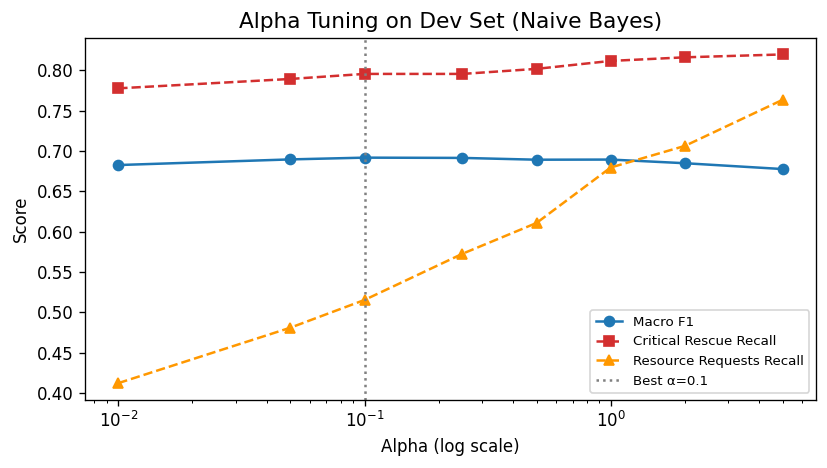

In [9]:
# Pick best alpha by macro F1 on dev set
best_row   = dev_df_results.loc[dev_df_results["macro_f1"].idxmax()]
best_alpha = best_row["alpha"]
print(f"Best alpha = {best_alpha}  (dev macro F1 = {best_row['macro_f1']:.4f})")

# Plot alpha vs dev macro-F1
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(dev_df_results["alpha"], dev_df_results["macro_f1"], marker="o", label="Macro F1")
ax.plot(dev_df_results["alpha"], dev_df_results["critical_rescue_recall"],
        marker="s", linestyle="--", color="#d32f2f", label="Critical Rescue Recall")
ax.plot(dev_df_results["alpha"], dev_df_results["resource_requests_recall"],
        marker="^", linestyle="--", color="#ff9800", label="Resource Requests Recall")
ax.axvline(best_alpha, color="grey", linestyle=":", label=f"Best α={best_alpha}")
ax.set_xscale("log")
ax.set_xlabel("Alpha (log scale)")
ax.set_ylabel("Score")
ax.set_title("Alpha Tuning on Dev Set (Naive Bayes)", fontsize=13)
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "alpha_tuning_nb.png"), dpi=150, bbox_inches="tight")
plt.show()

## 6. Train Final Naive Bayes Model

Training on the full training set with the best alpha found on the dev set.

In [10]:
print(f"Training MultinomialNB with alpha={best_alpha} ...")
nb_final = MultinomialNB(alpha=best_alpha)
nb_final.fit(X_train, y_train, sample_weight=sample_weights)
y_pred = nb_final.predict(X_test)
print("Training complete!")

Training MultinomialNB with alpha=0.1 ...
Training complete!


## 7. Evaluation

### 7.1 Classification Report

In [11]:
print(classification_report(
    y_test, y_pred,
    target_names=CLASS_ORDER,
    labels=CLASS_ORDER,
    zero_division=0,
))

                            precision    recall  f1-score   support

           Critical Rescue       0.78      0.79      0.78      2167
         Resource Requests       0.38      0.53      0.45       516
Volunteering and Donations       0.77      0.81      0.79      4133
     Situational Awareness       0.80      0.71      0.75      4993
                Irrelevant       0.65      0.69      0.67      2902

                  accuracy                           0.74     14711
                 macro avg       0.68      0.71      0.69     14711
              weighted avg       0.75      0.74      0.74     14711



### 7.2 Confusion Matrix

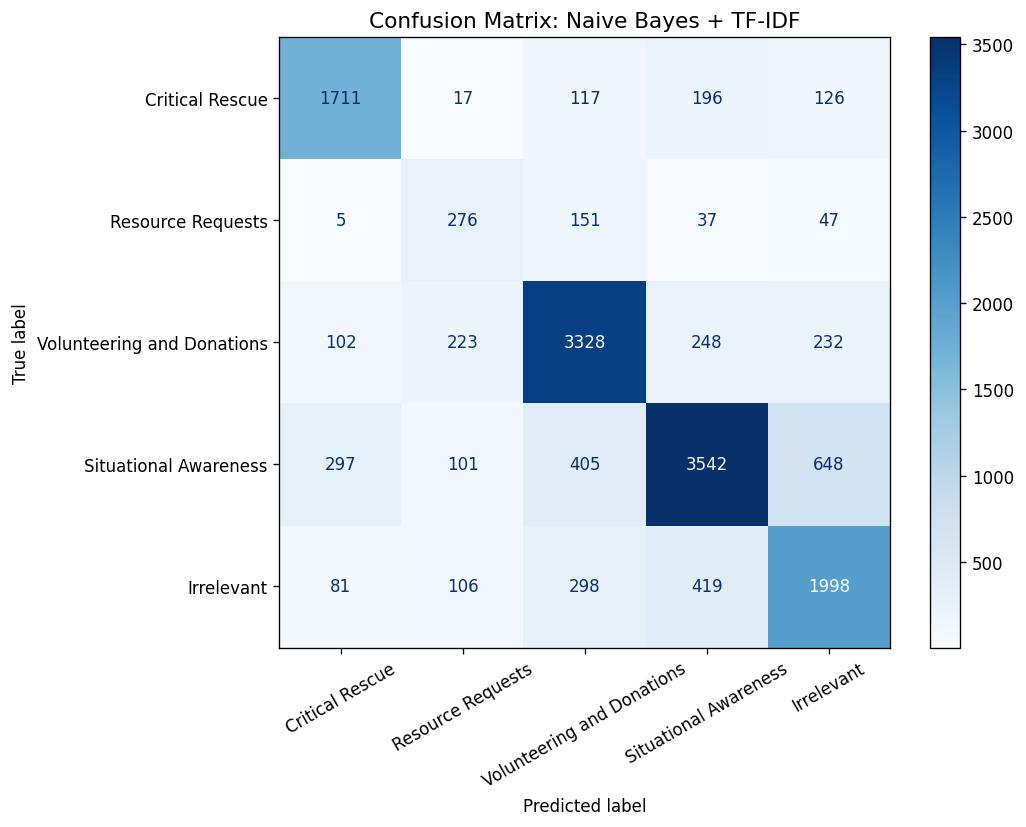

In [12]:
cm = confusion_matrix(y_test, y_pred, labels=CLASS_ORDER)

fig, ax = plt.subplots(figsize=(9, 7))
disp = ConfusionMatrixDisplay(cm, display_labels=CLASS_ORDER)
disp.plot(ax=ax, cmap="Blues", xticks_rotation=30)
ax.set_title("Confusion Matrix: Naive Bayes + TF-IDF", fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "cm_nb.png"), dpi=150, bbox_inches="tight")
plt.show()

### 7.3 Per-Class Recall

Recall is the priority metric — in disaster response, missing an urgent message is far worse than a false alarm.

In [13]:
report_dict = classification_report(
    y_test, y_pred,
    target_names=CLASS_ORDER,
    labels=CLASS_ORDER,
    output_dict=True,
    zero_division=0,
)

print(f"{'Class':30s}  {'Precision':>9s}  {'Recall':>6s}  {'F1':>6s}  {'Support':>7s}")
print("-" * 65)
for cls in CLASS_ORDER:
    r = report_dict[cls]
    print(f"{cls:30s}  {r['precision']:9.3f}  {r['recall']:6.3f}  {r['f1-score']:6.3f}  {int(r['support']):7d}")
print("-" * 65)
print(f"{'Macro Avg':30s}  {report_dict['macro avg']['precision']:9.3f}  "
      f"{report_dict['macro avg']['recall']:6.3f}  {report_dict['macro avg']['f1-score']:6.3f}")
print(f"{'Weighted Avg':30s}  {report_dict['weighted avg']['precision']:9.3f}  "
      f"{report_dict['weighted avg']['recall']:6.3f}  {report_dict['weighted avg']['f1-score']:6.3f}")

Class                           Precision  Recall      F1  Support
-----------------------------------------------------------------
Critical Rescue                     0.779   0.790   0.784     2167
Resource Requests                   0.382   0.535   0.446      516
Volunteering and Donations          0.774   0.805   0.789     4133
Situational Awareness               0.797   0.709   0.751     4993
Irrelevant                          0.655   0.688   0.671     2902
-----------------------------------------------------------------
Macro Avg                           0.677   0.706   0.688
Weighted Avg                        0.745   0.738   0.740


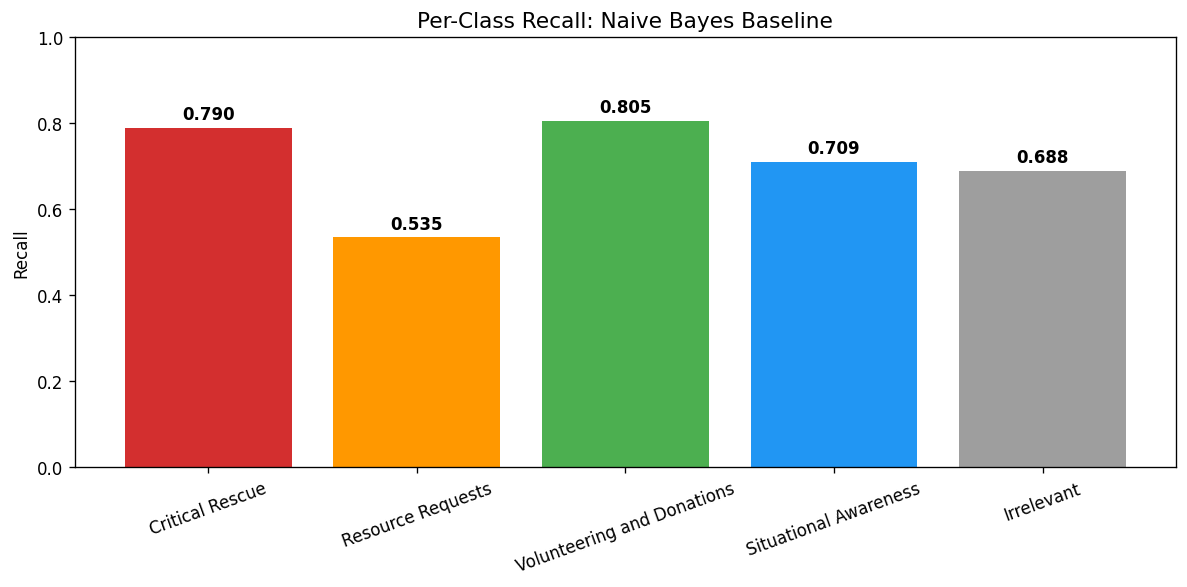

In [14]:
# Plot per-class recall
fig, ax = plt.subplots(figsize=(10, 5))
recalls    = [report_dict[c]["recall"] for c in CLASS_ORDER]
bar_colors = [CLASS_COLORS[c] for c in CLASS_ORDER]
ax.bar(CLASS_ORDER, recalls, color=bar_colors)
ax.set_ylabel("Recall")
ax.set_title("Per-Class Recall: Naive Bayes Baseline", fontsize=13)
ax.set_ylim(0, 1)
ax.tick_params(axis="x", rotation=20)
for i, r in enumerate(recalls):
    ax.text(i, r + 0.02, f"{r:.3f}", ha="center", fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "recall_nb.png"), dpi=150, bbox_inches="tight")
plt.show()

## 8. Error Analysis

### 8.1 Dangerous False Negatives

Urgent messages (Critical Rescue / Resource Requests) misclassified as non-urgent (Situational Awareness / Irrelevant). These are the most costly errors in a disaster response system.

In [15]:
test_analysis = test_df.copy()
test_analysis["pred_label"] = y_pred
test_analysis["correct"]    = y_test.values == y_pred

urgent     = ["Critical Rescue", "Resource Requests"]
non_urgent = ["Situational Awareness", "Irrelevant"]

dangerous_fn = test_analysis[
    (test_analysis["target_label"].isin(urgent)) &
    (test_analysis["pred_label"].isin(non_urgent))
]

total_urgent = len(test_analysis[test_analysis["target_label"].isin(urgent)])
print(f"Total urgent messages in test set: {total_urgent}")
print(f"Dangerous false negatives: {len(dangerous_fn)} ({len(dangerous_fn)/total_urgent*100:.1f}% of urgent messages)")
print(f"  Critical Rescue → non-urgent:   "
      f"{len(dangerous_fn[dangerous_fn['target_label']=='Critical Rescue'])}")
print(f"  Resource Requests → non-urgent:  "
      f"{len(dangerous_fn[dangerous_fn['target_label']=='Resource Requests'])}")

Total urgent messages in test set: 2683
Dangerous false negatives: 406 (15.1% of urgent messages)
  Critical Rescue → non-urgent:   322
  Resource Requests → non-urgent:  84


In [16]:
print(f"\nExamples:")
print("-" * 70)
for _, row in dangerous_fn.head(8).iterrows():
    print(f"  TRUE: {row['target_label']}  →  PRED: {row['pred_label']}")
    print(f"  TEXT: {row['tweet_text'][:140]}")
    print()


Examples:
----------------------------------------------------------------------
  TRUE: Critical Rescue  →  PRED: Situational Awareness
  TEXT: A great personal story by @kylemuzyka, a Slave Lake evacuee, about the lasting effects of a wildfire and evacuation.

  TRUE: Critical Rescue  →  PRED: Situational Awareness
  TEXT: CANADA ALBERTA: #FortMacFire damage: oil firms plan restart: 88K evacuees; 2400 buildings destroyed; #WTP operating

  TRUE: Critical Rescue  →  PRED: Situational Awareness
  TEXT: As MLA for Lesser Slave Lake, @DanielleLarivee stresses she understands the strains of a wildfire evacuation. #ableg #rmwbcouncil

  TRUE: Critical Rescue  →  PRED: Irrelevant
  TEXT: Fort McMurray video shows evacuee’s terrifying wildfire escape  via @torontostar..our thoughts are with you!

  TRUE: Critical Rescue  →  PRED: Situational Awareness
  TEXT: RT @paterson_sam: Satellite imagery helps #ymmfire evacuees

  TRUE: Critical Rescue  →  PRED: Situational Awareness
  TEXT: FYI @You

### 8.2 Critical Rescue ↔ Resource Requests Confusion

In [17]:
rescue_as_resource = test_analysis[
    (test_analysis["target_label"] == "Critical Rescue") &
    (test_analysis["pred_label"]   == "Resource Requests")
]
resource_as_rescue = test_analysis[
    (test_analysis["target_label"] == "Resource Requests") &
    (test_analysis["pred_label"]   == "Critical Rescue")
]

print(f"Critical Rescue → Resource Requests: {len(rescue_as_resource)}")
print(f"Resource Requests → Critical Rescue: {len(resource_as_rescue)}")

print(f"\nCritical Rescue misclassified as Resource Requests:")
for _, row in rescue_as_resource.head(5).iterrows():
    print(f"  > {row['tweet_text'][:140]}")
    print()

print(f"Resource Requests misclassified as Critical Rescue:")
for _, row in resource_as_rescue.head(5).iterrows():
    print(f"  > {row['tweet_text'][:140]}")
    print()

Critical Rescue → Resource Requests: 17
Resource Requests → Critical Rescue: 5

Critical Rescue misclassified as Resource Requests:
  > 2. Mr. President, @edmnangagwa Did we need to get to 30 deaths for us to do something meaningful? Someone slept on the job sir. Please let’s

  > #CycloneIdai has killed hundreds and affected millions in #Mozambique, #Malawi &amp; #Zimbabwe. CARE is joining @decappeal members in launch

  > Items need for evacuees.  #HurricaneHarvey #Austin

  > Why are we accepting evacuees in Alabama when we still have homeless veterans? #IfEvacueesWereRefugees #IrmaHurricane2017

  > Read and share: Special Needs and General Shelters to Open ahead of #HurricaneIrma #TBTIrma

Resource Requests misclassified as Critical Rescue:
  > Cyclone Idai: Mozambique survivors desperate for help - BBC News

  > DNA Samples Needed to Identify Camp Fire Victims

  > California seeks disaster aid as wildfire death toll mounts  via @business

  > ***New Episode*** Wildlife refuge lo

### 8.3 Per-Class Accuracy

In [18]:
print(f"{'Class':30s}  {'Accuracy':>8s}  {'Correct':>7s}  {'Total':>5s}")
print("-" * 55)
for label in CLASS_ORDER:
    subset = test_analysis[test_analysis["target_label"] == label]
    if len(subset) > 0:
        acc = subset["correct"].mean()
        print(f"{label:30s}  {acc:8.3f}  {subset['correct'].sum():7d}  {len(subset):5d}")

Class                           Accuracy  Correct  Total
-------------------------------------------------------
Critical Rescue                    0.790     1711   2167
Resource Requests                  0.535      276    516
Volunteering and Donations         0.805     3328   4133
Situational Awareness              0.709     3542   4993
Irrelevant                         0.688     1998   2902


## 9. SVM vs Naive Bayes — Side-by-Side Comparison

Load the previously saved SVM results and compare directly.

In [20]:
svm_results_path = os.path.join(BASE_DIR, "results", "svm_results.json")

if os.path.exists(svm_results_path):
    with open(svm_results_path) as f:
        svm_report = json.load(f)

    print(f"{'Metric':<40s}  {'SVM':>8s}  {'Naive Bayes':>11s}  {'Δ (NB-SVM)':>11s}")
    print("-" * 75)

    metrics = [
        ("Macro F1",                 "macro avg",      "f1-score"),
        ("Weighted F1",              "weighted avg",   "f1-score"),
        ("Critical Rescue — Recall", "Critical Rescue","recall"),
        ("Resource Requests — Recall","Resource Requests","recall"),
        ("Irrelevant — Recall",       "Irrelevant",    "recall"),
        ("Situational Awareness — Recall", "Situational Awareness", "recall"),
    ]

    for label, key, sub in metrics:
        svm_val = svm_report[key][sub]
        nb_val  = report_dict[key][sub]
        delta   = nb_val - svm_val
        sign    = "+" if delta >= 0 else ""
        print(f"{label:<40s}  {svm_val:8.3f}  {nb_val:11.3f}  {sign}{delta:+.3f}")
else:
    print("svm_results.json not found — run the SVM notebook first, then re-run this cell.")
    print("\nNaive Bayes results only:")
    print(f"  Macro F1:    {report_dict['macro avg']['f1-score']:.3f}")
    print(f"  Weighted F1: {report_dict['weighted avg']['f1-score']:.3f}")
    print(f"  Critical Rescue Recall:    {report_dict['Critical Rescue']['recall']:.3f}")
    print(f"  Resource Requests Recall:  {report_dict['Resource Requests']['recall']:.3f}")

Metric                                         SVM  Naive Bayes   Δ (NB-SVM)
---------------------------------------------------------------------------
Macro F1                                     0.754        0.688  -0.066
Weighted F1                                  0.796        0.740  -0.056
Critical Rescue — Recall                     0.911        0.790  -0.122
Resource Requests — Recall                   0.543        0.535  -0.008
Irrelevant — Recall                          0.682        0.688  ++0.006
Situational Awareness — Recall               0.796        0.709  -0.087


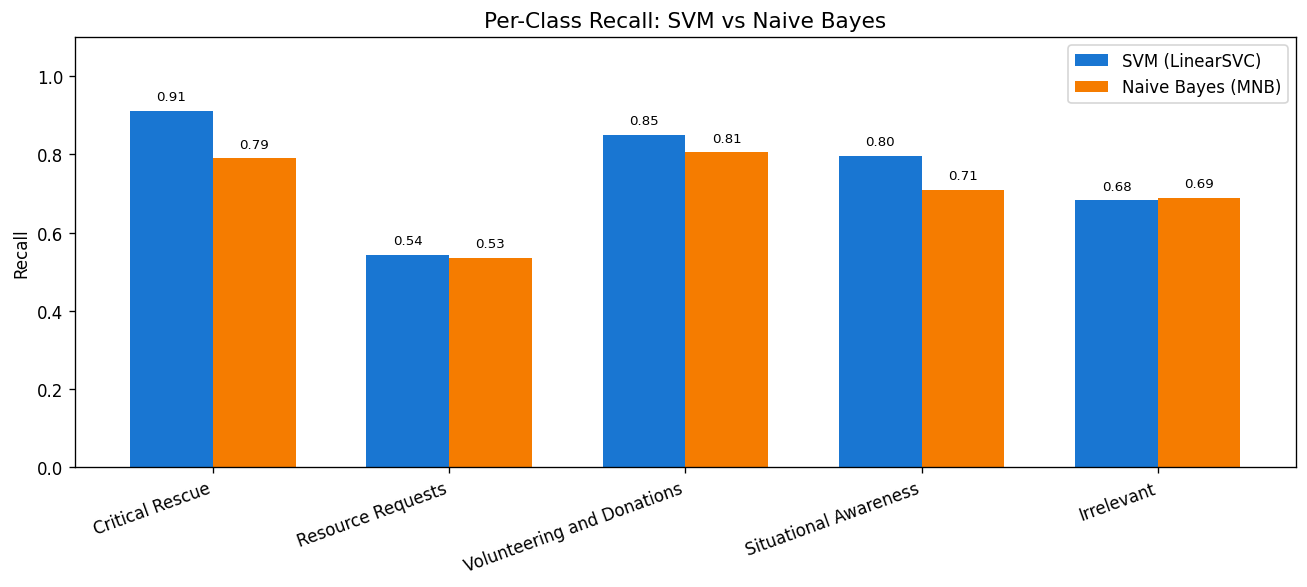

In [21]:
# Visualise recall comparison (SVM vs NB) if SVM results are available
if os.path.exists(svm_results_path):
    svm_recalls = [svm_report[c]["recall"] for c in CLASS_ORDER]
    nb_recalls  = [report_dict[c]["recall"]  for c in CLASS_ORDER]

    x = np.arange(len(CLASS_ORDER))
    width = 0.35

    fig, ax = plt.subplots(figsize=(11, 5))
    bars1 = ax.bar(x - width/2, svm_recalls, width, label="SVM (LinearSVC)",    color="#1976d2")
    bars2 = ax.bar(x + width/2, nb_recalls,  width, label="Naive Bayes (MNB)", color="#f57c00")

    ax.set_xticks(x)
    ax.set_xticklabels(CLASS_ORDER, rotation=20, ha="right")
    ax.set_ylabel("Recall")
    ax.set_ylim(0, 1.1)
    ax.set_title("Per-Class Recall: SVM vs Naive Bayes", fontsize=13)
    ax.legend()

    for bar in bars1:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=8)
    for bar in bars2:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=8)

    plt.tight_layout()
    plt.savefig(os.path.join(PLOTS_DIR, "recall_comparison_svm_vs_nb.png"), dpi=150, bbox_inches="tight")
    plt.show()

## 10. Save Results

In [22]:
# Save all misclassifications for manual review
errors = test_analysis[~test_analysis["correct"]].sort_values("target_label")
errors.to_csv(os.path.join(BASE_DIR, "results", "nb_errors.csv"), index=False)
print(f"Saved {len(errors)} misclassified samples to results/nb_errors.csv")

# Save classification report
results_path = os.path.join(BASE_DIR, "results", "nb_results.json")
with open(results_path, "w") as f:
    json.dump(report_dict, f, indent=2)
print(f"Saved classification report to {results_path}")

print(f"\nNaive Bayes Baseline Summary:")
print(f"  Best alpha:  {best_alpha}")
print(f"  Macro F1:    {report_dict['macro avg']['f1-score']:.3f}")
print(f"  Weighted F1: {report_dict['weighted avg']['f1-score']:.3f}")
print(f"  Critical Rescue Recall:    {report_dict['Critical Rescue']['recall']:.3f}")
print(f"  Resource Requests Recall:  {report_dict['Resource Requests']['recall']:.3f}")
print(f"  Dangerous FNs: {len(dangerous_fn)} ({len(dangerous_fn)/total_urgent*100:.1f}% of urgent)")

Saved 3856 misclassified samples to results/nb_errors.csv
Saved classification report to D:/NLP_PROJECT\results\nb_results.json

Naive Bayes Baseline Summary:
  Best alpha:  0.1
  Macro F1:    0.688
  Weighted F1: 0.740
  Critical Rescue Recall:    0.790
  Resource Requests Recall:  0.535
  Dangerous FNs: 406 (15.1% of urgent)


## 11. Summary

| Metric | Score |
|---|---|
| Best Alpha | 0.1 |
| Macro F1 | 0.688 |
| Weighted F1 | 0.740 |
| Critical Rescue Recall | 0.790 |
| Resource Requests Recall | 0.535 |
| Dangerous False Negatives | 406(15.1% of urgent) |

**Key takeaways vs SVM baseline:**
- MultinomialNB is significantly faster to train (near-instant even at 50k samples).
- NB typically underperforms SVM on F1 for text classification, especially on minority classes.
- NB offers easy interpretability via `feature_log_prob_` — useful for understanding what words drive each class.
- The "Dangerous False Negative" rate is the key safety metric for this project.

**Next:** Open `Baseline_LogisticRegression.ipynb`

# **Naive Bayes - Munro Dataset**

**Project:** Multilingual Classification of Urgent Disaster Response Messages  
**Input:** `disaster_processed_training.csv`, `disaster_processed_validation.csv`, `disaster_processed_test.csv` (from Notebook 01)

This section:
1. Loads processed Munro/Disaster Response splits
2. TF-IDF vectorization (same settings as SVM)
3. Tunes MultinomialNB alpha on validation split
4. Evaluates on test set
5. Performs error analysis and saves results

## 1. Configuration and Data Loading

In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.preprocessing import MaxAbsScaler
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

import warnings
warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 120

print("All imports successful for Munro NB section!")

All imports successful for Munro NB section!


In [2]:
# Update this path to your local project root if needed
BASE_DIR = r"D:/WORKING_PROJECTS/NLP_PROJECT"

PROCESSED_DIR = os.path.join(BASE_DIR, "datasets", "processed")
RESULTS_DIR = os.path.join(BASE_DIR, "results")
PLOTS_DIR = {
    "nb": os.path.join(RESULTS_DIR, "plots", "nb_dr"),
}

CLASS_ORDER = [
    "Critical Rescue",
    "Resource Requests",
    "Volunteering and Donations",
    "Situational Awareness",
    "Irrelevant",
]

CLASS_COLORS = {
    "Critical Rescue":             "#d32f2f",
    "Resource Requests":           "#ff9800",
    "Volunteering and Donations":  "#4caf50",
    "Situational Awareness":       "#2196f3",
    "Irrelevant":                  "#9e9e9e",
}

for folder in PLOTS_DIR.values():
    os.makedirs(folder, exist_ok=True)

train_df = pd.read_csv(os.path.join(PROCESSED_DIR, "disaster_processed_training.csv"))
dev_df   = pd.read_csv(os.path.join(PROCESSED_DIR, "disaster_processed_validation.csv"))
test_df  = pd.read_csv(os.path.join(PROCESSED_DIR, "disaster_processed_test.csv"))

print(f"Loaded - Train: {len(train_df)}, Val: {len(dev_df)}, Test: {len(test_df)}")
print(f"Columns: {list(train_df.columns)}")
print("\nTrain class distribution:")
print(train_df["target_label"].value_counts().reindex(CLASS_ORDER))

Loaded - Train: 19112, Val: 2336, Test: 2397
Columns: ['id', 'message', 'original', 'genre', 'event', 'split', 'target_label', 'clean_text', 'text_length', 'word_count']

Train class distribution:
target_label
Critical Rescue                1913
Resource Requests              1991
Volunteering and Donations      115
Situational Awareness          4305
Irrelevant                    10788
Name: count, dtype: int64


## 2. TF-IDF Vectorization

Using the same feature settings as the SVM Munro baseline.

In [3]:
tfidf = TfidfVectorizer(
    max_features=30000,
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.95,
    sublinear_tf=True,
)

X_train_raw = tfidf.fit_transform(train_df["clean_text"])
X_dev_raw   = tfidf.transform(dev_df["clean_text"])
X_test_raw  = tfidf.transform(test_df["clean_text"])

y_train = train_df["target_label"]
y_dev   = dev_df["target_label"]
y_test  = test_df["target_label"]

scaler = MaxAbsScaler()
X_train = scaler.fit_transform(X_train_raw)
X_dev   = scaler.transform(X_dev_raw)
X_test  = scaler.transform(X_test_raw)

print(f"TF-IDF vocabulary size: {len(tfidf.vocabulary_)}")
print(f"X_train shape: {X_train.shape}")
print(f"X_val shape:   {X_dev.shape}")
print(f"X_test shape:  {X_test.shape}")

TF-IDF vocabulary size: 30000
X_train shape: (19112, 30000)
X_val shape:   (2336, 30000)
X_test shape:  (2397, 30000)


## 3. Tune Alpha and Train Naive Bayes

Tune on validation split, then evaluate the best model on the test split.

In [4]:
alphas = [0.01, 0.05, 0.1, 0.25, 0.5, 1.0, 2.0, 5.0]

sample_weights = compute_sample_weight(class_weight="balanced", y=y_train)

val_rows = []
for alpha in alphas:
    model = MultinomialNB(alpha=alpha)
    model.fit(X_train, y_train, sample_weight=sample_weights)
    y_val_pred = model.predict(X_dev)
    val_report = classification_report(
        y_dev,
        y_val_pred,
        labels=CLASS_ORDER,
        target_names=CLASS_ORDER,
        output_dict=True,
        zero_division=0,
    )
    val_rows.append({
        "alpha": alpha,
        "macro_f1": val_report["macro avg"]["f1-score"],
        "weighted_f1": val_report["weighted avg"]["f1-score"],
        "critical_rescue_recall": val_report["Critical Rescue"]["recall"],
        "resource_requests_recall": val_report["Resource Requests"]["recall"],
    })

val_results = pd.DataFrame(val_rows).sort_values("macro_f1", ascending=False)
best_alpha = float(val_results.iloc[0]["alpha"])

print("Validation results (sorted by macro F1):")
print(val_results.to_string(index=False))
print(f"\nBest alpha: {best_alpha}")

nb_dr = MultinomialNB(alpha=best_alpha)
nb_dr.fit(X_train, y_train, sample_weight=sample_weights)
y_pred = nb_dr.predict(X_test)
print("\nFinal Naive Bayes model trained on Munro training split.")

Validation results (sorted by macro F1):
 alpha  macro_f1  weighted_f1  critical_rescue_recall  resource_requests_recall
  0.05  0.435269     0.631936                0.447964                  0.734440
  0.25  0.432313     0.623250                0.479638                  0.784232
  0.01  0.432297     0.631783                0.402715                  0.709544
  0.10  0.428714     0.625676                0.447964                  0.742739
  0.50  0.428028     0.614383                0.497738                  0.800830
  1.00  0.426151     0.597529                0.520362                  0.825726
  2.00  0.423684     0.568532                0.561086                  0.825726
  5.00  0.393642     0.512246                0.606335                  0.834025

Best alpha: 0.05

Final Naive Bayes model trained on Munro training split.


## 4. Evaluation

                            precision    recall  f1-score   support

           Critical Rescue       0.42      0.53      0.47       214
         Resource Requests       0.45      0.72      0.55       295
Volunteering and Donations       0.12      0.01      0.02       116
     Situational Awareness       0.58      0.49      0.53       563
                Irrelevant       0.74      0.71      0.73      1209

                  accuracy                           0.61      2397
                 macro avg       0.46      0.49      0.46      2397
              weighted avg       0.61      0.61      0.60      2397



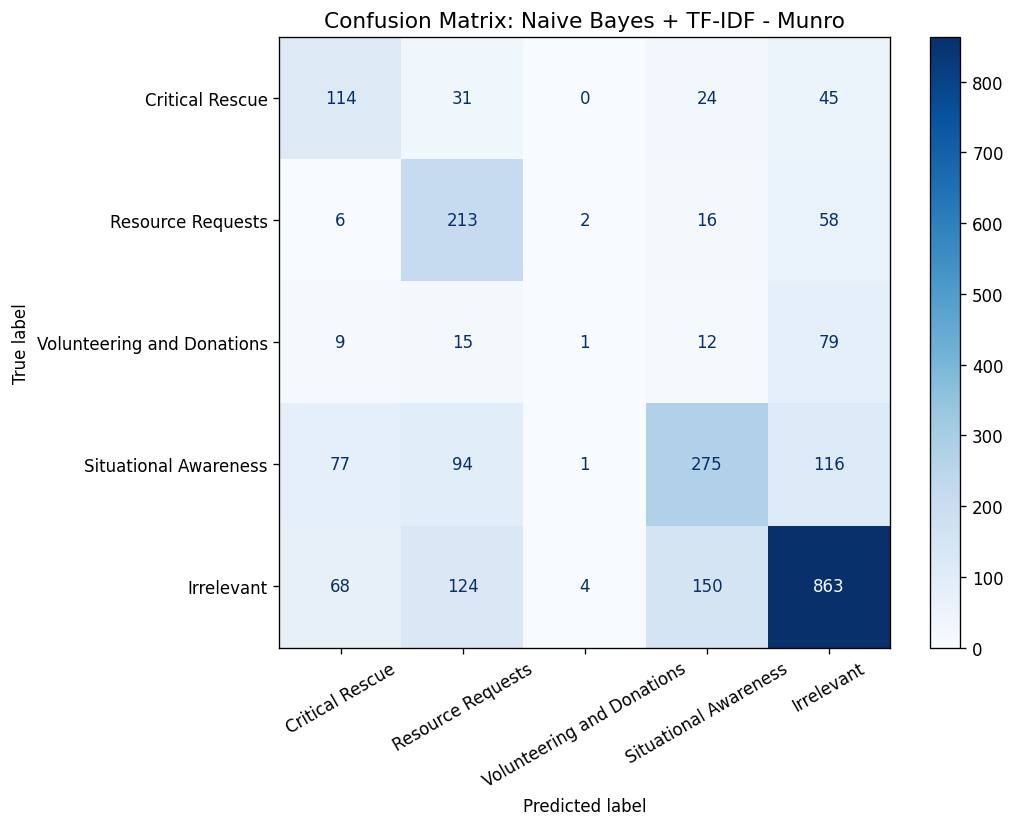

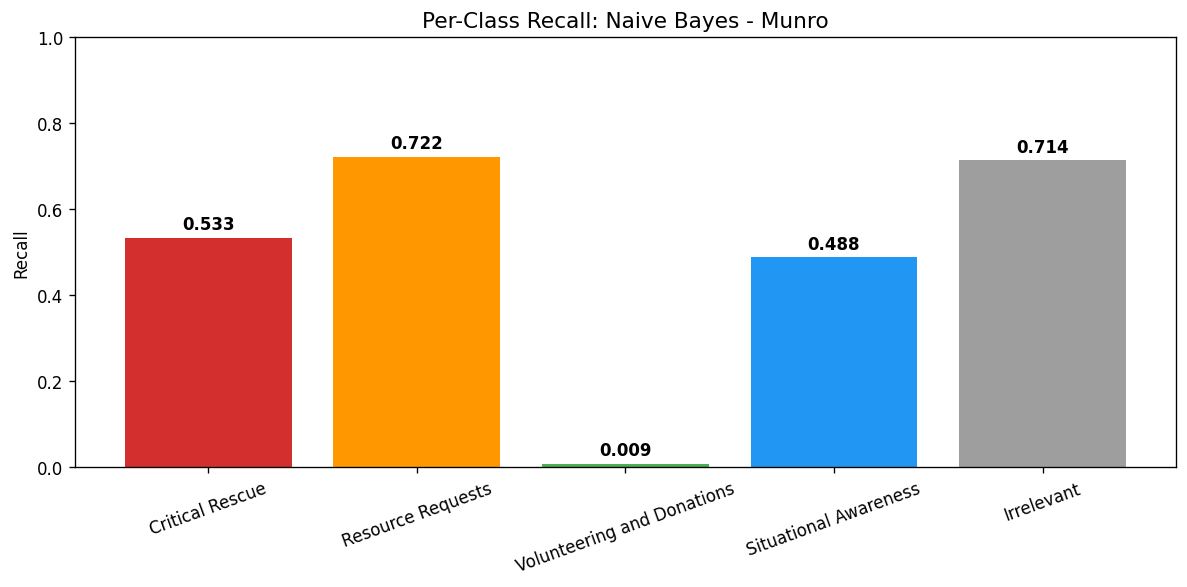


Macro F1:    0.458
Weighted F1: 0.602


In [5]:
print(classification_report(
    y_test, y_pred,
    target_names=CLASS_ORDER,
    labels=CLASS_ORDER,
    zero_division=0,
))

report_dict = classification_report(
    y_test, y_pred,
    target_names=CLASS_ORDER,
    labels=CLASS_ORDER,
    output_dict=True,
    zero_division=0,
)

cm = confusion_matrix(y_test, y_pred, labels=CLASS_ORDER)
fig, ax = plt.subplots(figsize=(9, 7))
disp = ConfusionMatrixDisplay(cm, display_labels=CLASS_ORDER)
disp.plot(ax=ax, cmap="Blues", xticks_rotation=30)
ax.set_title("Confusion Matrix: Naive Bayes + TF-IDF - Munro", fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR["nb"], "cm_nb_dr.png"), dpi=150, bbox_inches="tight")
plt.show()

recalls = [report_dict[c]["recall"] for c in CLASS_ORDER]
bar_colors = [CLASS_COLORS[c] for c in CLASS_ORDER]

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(CLASS_ORDER, recalls, color=bar_colors)
ax.set_ylabel("Recall")
ax.set_title("Per-Class Recall: Naive Bayes - Munro", fontsize=13)
ax.set_ylim(0, 1)
ax.tick_params(axis="x", rotation=20)
for i, r in enumerate(recalls):
    ax.text(i, r + 0.02, f"{r:.3f}", ha="center", fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR["nb"], "recall_nb_dr.png"), dpi=150, bbox_inches="tight")
plt.show()

print(f"\nMacro F1:    {report_dict['macro avg']['f1-score']:.3f}")
print(f"Weighted F1: {report_dict['weighted avg']['f1-score']:.3f}")

## 5. Error Analysis

### 5.1 Dangerous False Negatives

In [6]:
test_analysis = test_df.copy()
test_analysis["pred_label"] = y_pred
test_analysis["correct"] = y_test.values == y_pred

urgent = ["Critical Rescue", "Resource Requests"]
non_urgent = ["Situational Awareness", "Irrelevant"]

dangerous_fn = test_analysis[
    (test_analysis["target_label"].isin(urgent)) &
    (test_analysis["pred_label"].isin(non_urgent))
]

total_urgent = len(test_analysis[test_analysis["target_label"].isin(urgent)])
dangerous_rate = (len(dangerous_fn) / total_urgent * 100) if total_urgent else 0.0
print(f"Total urgent messages in test set: {total_urgent}")
print(f"Dangerous false negatives: {len(dangerous_fn)} ({dangerous_rate:.1f}% of urgent messages)")

print("\nExamples:")
print("-" * 70)
for _, row in dangerous_fn.head(8).iterrows():
    print(f"  TRUE: {row['target_label']}  ->  PRED: {row['pred_label']}")
    print(f"  TEXT: {str(row['message'])[:140]}")
    print()

Total urgent messages in test set: 509
Dangerous false negatives: 143 (28.1% of urgent messages)

Examples:
----------------------------------------------------------------------
  TRUE: Resource Requests  ->  PRED: Irrelevant
  TEXT: UN reports Leogane 80-90 destroyed. Only Hospital St. Croix functioning. Needs supplies desperately.

  TRUE: Resource Requests  ->  PRED: Irrelevant
  TEXT: My necessities are not complex. I don't have money right now to be able to get on the internet. So, that is why I am telling you a little ab

  TRUE: Critical Rescue  ->  PRED: Irrelevant
  TEXT: I need to know if someone who is in the military can send for his or her family

  TRUE: Resource Requests  ->  PRED: Irrelevant
  TEXT: It's advised to airdrop food kits to rural houses and the slums. The silent are also hungry.

  TRUE: Resource Requests  ->  PRED: Irrelevant
  TEXT: hello to you, please, i would like to know how to find care for my husband, he is fractured in hand and foot and cannot walk

### 5.2 Per-Class Accuracy

In [10]:
print(f"{'Class':30s}  {'Accuracy':>8s}  {'Correct':>7s}  {'Total':>5s}")
print("-" * 55)
for label in CLASS_ORDER:
    subset = test_analysis[test_analysis["target_label"] == label]
    if len(subset) > 0:
        acc = subset["correct"].mean()
        print(f"{label:30s}  {acc:8.3f}  {subset['correct'].sum():7d}  {len(subset):5d}")

Class                           Accuracy  Correct  Total
-------------------------------------------------------
Critical Rescue                    0.533      114    214
Resource Requests                  0.722      213    295
Volunteering and Donations         0.009        1    116
Situational Awareness              0.488      275    563
Irrelevant                         0.714      863   1209


## 6. Save Results

In [7]:
errors = test_analysis[~test_analysis["correct"]].sort_values("target_label")
errors_path = os.path.join(RESULTS_DIR, "nb_dr_errors.csv")
errors.to_csv(errors_path, index=False)
print(f"Saved {len(errors)} misclassified samples to {errors_path}")

results_path = os.path.join(RESULTS_DIR, "nb_dr_results.json")
with open(results_path, "w") as f:
    json.dump(report_dict, f, indent=2)
print(f"Saved classification report to {results_path}")

print("\nNaive Bayes Baseline Summary (Munro):")
print(f"  Best alpha:  {best_alpha}")
print(f"  Macro F1:    {report_dict['macro avg']['f1-score']:.3f}")
print(f"  Weighted F1: {report_dict['weighted avg']['f1-score']:.3f}")
print(f"  Dangerous FNs: {len(dangerous_fn)} ({dangerous_rate:.1f}% of urgent)")

Saved 931 misclassified samples to D:/WORKING_PROJECTS/NLP_PROJECT\results\nb_dr_errors.csv
Saved classification report to D:/WORKING_PROJECTS/NLP_PROJECT\results\nb_dr_results.json

Naive Bayes Baseline Summary (Munro):
  Best alpha:  0.05
  Macro F1:    0.458
  Weighted F1: 0.602
  Dangerous FNs: 143 (28.1% of urgent)


## 7. SVM vs Naive Bayes (Munro)

Compare with previously saved SVM Munro results (`svm_dr_results.json`).

In [8]:
svm_dr_results_path = os.path.join(RESULTS_DIR, "svm_dr_results.json")

if os.path.exists(svm_dr_results_path):
    with open(svm_dr_results_path) as f:
        svm_report = json.load(f)

    print(f"{'Metric':<38s}  {'SVM':>8s}  {'Naive Bayes':>11s}  {'Delta (NB-SVM)':>15s}")
    print("-" * 80)

    metrics = [
        ("Accuracy", "accuracy", None),
        ("Macro F1", "macro avg", "f1-score"),
        ("Weighted F1", "weighted avg", "f1-score"),
        ("Critical Rescue Recall", "Critical Rescue", "recall"),
        ("Resource Requests Recall", "Resource Requests", "recall"),
        ("Irrelevant Recall", "Irrelevant", "recall"),
    ]

    for label, key, sub in metrics:
        if sub is None:
            svm_val = svm_report[key]
            nb_val = report_dict[key]
        else:
            svm_val = svm_report[key][sub]
            nb_val = report_dict[key][sub]

        delta = nb_val - svm_val
        print(f"{label:<38s}  {svm_val:8.3f}  {nb_val:11.3f}  {delta:+15.3f}")
else:
    print("svm_dr_results.json not found. Run the SVM Munro section first, then rerun this cell.")

Metric                                       SVM  Naive Bayes   Delta (NB-SVM)
--------------------------------------------------------------------------------
Accuracy                                   0.713        0.612           -0.101
Macro F1                                   0.554        0.458           -0.096
Weighted F1                                0.692        0.602           -0.090
Critical Rescue Recall                     0.650        0.533           -0.117
Resource Requests Recall                   0.651        0.722           +0.071
Irrelevant Recall                          0.865        0.714           -0.151
